In [12]:
import json
from typing import Optional, Tuple
import math
import matplotlib.pyplot as plt

In [2]:
folder = '/home/ppelikh/dev/pycharm/Subgradient'

In [3]:
def generate_side_by_side_tables(subgrad_key: str = 'subgrad_logs',
                                 lbfgs_key: str = 'lbfgs_logs') -> str:
    r"""
    Generates LaTeX code for two side-by-side tabular tables (minipages)
    covering half of the tests each, sorted by solution_rank ascending but
    displaying original test numbers. Time is rounded to 3 decimals.
    Methods renamed to "S" and "L" to save space.

    Preamble needs:
      \usepackage{booktabs}
      \usepackage{multirow}
    """
    # Load tests and annotate original indices
    tests = []
    for i in [0, 1, 3]:
        with open(folder + f'/data/test{i}.json', 'r') as f:
            test = json.load(f)
            test['orig_no'] = i
            tests.append(test)
    
    with open(folder + f'/data/test2_subgrad.json', 'r') as f:
        test2 = json.load(f)

    test2['lbfgs_logs'] = []
    with open(folder + f'/data/test2_lbfgs_3.json', 'r') as f:
        p1 = json.load(f)
        test2['lbfgs_logs'].append(p1['lbfgs_logs'][0])
    with open(folder + f'/data/test2_lbfgs_4.json', 'r') as f:
        p2 = json.load(f)
        test2['lbfgs_logs'].append(p2['lbfgs_logs'][0])
    with open(folder + f'/data/test2_lbfgs_5.json', 'r') as f:
        p3 = json.load(f)
        test2['lbfgs_logs'].append(p3['lbfgs_logs'][0])
    with open(folder + f'/data/test2_lbfgs_6.json', 'r') as f:
        p4 = json.load(f)
        test2['lbfgs_logs'].append(p4['lbfgs_logs'][0])
    test2['orig_no'] = 2
    tests.append(test2)

    # Sort by solution_rank
    tests_sorted = sorted(tests, key=lambda t: t.get('solution_rank', 0))
    n = len(tests_sorted)
    half = n // 2

    # Method names shortened
    methods = [('S', subgrad_key), ('L', lbfgs_key)]

    def tabular_for_group(group_tests):
        lines = []
        lines.append(r"\setlength{\tabcolsep}{3pt}")
        # lines.append(r"\renewcommand{\arraystretch}{1.1}")
        lines.append(r"\begin{tabular}{@{} c c c c r r c c @{}}")
        lines.append(r"\toprule")
        # Shortened header: Mtd -> M
        lines.append(r"Test & Rank & Tol. & M & Time & Iters & Ach. & Err. \\")
        lines.append(r"\midrule")
        
        labels = [
            'IG', 'IE', 'IT', 'IM',
            'RG', 'RE', 'RT', 'RM',
            'WP', 'WM', 'WC', 'WG'
        ]
        for test in group_tests:
            orig = r'\textbf{' + labels[test["orig_no"]] + r'}'
            rank = test.get('solution_rank', '')
            total_rows = 4 * len(methods)
            count = 0

            for method_name, key in methods:
                logs = test.get(key, [])
                for i, tol in enumerate(['1e-3', '1e-4', '1e-5', '1e-6']):
                    log = logs[i] if i < len(logs) else {}
                    rt = f"{log.get('time', 0.0):.3f}"
                    iters = len(log.get('loss_history', []))
                    ach = "Yes" if log.get('tol_reached', False) else "No"
                    err_val = abs(test.get('ground_truth', 0.0) -
                                  log.get('loss_history', [0.0])[-1])
                    err = f"{err_val:.1e}"

                    if count == 0:
                        lines.append(
                            rf"\multirow{{{total_rows}}}{{*}}{{{orig}}} & "
                            rf"\multirow{{{total_rows}}}{{*}}{{{rank}}} & "
                            rf"{tol} & {method_name} & {rt} & {iters} & {ach} & {err} \\"
                        )
                    else:
                        lines.append(
                            rf" &  & {tol} & {method_name} & {rt} & {iters} & {ach} & {err} \\"
                        )
                    count += 1

            lines.append(r"\midrule")
        lines[-1] = r"\bottomrule"  # replace last midrule with bottomrule
        lines.append(r"\end{tabular}")
        return "\n".join(lines)

    # Split sorted tests into two halves
    left_tests = tests_sorted[:half]
    right_tests = tests_sorted[half:]

    parts = []
    parts.append(r"\begin{table}[ht]")
    parts.append(r"\centering")
    parts.append(r"\small")
    parts.append(r"\begin{minipage}[t]{0.48\textwidth}")
    parts.append(tabular_for_group(left_tests))
    parts.append(r"\end{minipage}")
    parts.append(r"\hfill")
    parts.append(r"\begin{minipage}[t]{0.48\textwidth}")
    parts.append(tabular_for_group(right_tests))
    parts.append(r"\end{minipage}")
    parts.append(r"\caption{Comparison of S vs.\ L across tolerances}")
    parts.append(r"\label{tab:tests-sbs}")
    parts.append(r"\end{table}")

    return "\n".join(parts)

if __name__ == "__main__":
    print(generate_side_by_side_tables())

\begin{table}[ht]
\centering
\small
\begin{minipage}[t]{0.48\textwidth}
\setlength{\tabcolsep}{3pt}
\begin{tabular}{@{} c c c c r r c c @{}}
\toprule
Test & Rank & Tol. & M & Time & Iters & Ach. & Err. \\
\midrule
\multirow{8}{*}{\textbf{IG}} & \multirow{8}{*}{1} & 1e-3 & S & 0.185 & 198 & Yes & 2.0e-05 \\
 &  & 1e-4 & S & 0.426 & 543 & Yes & 5.0e-07 \\
 &  & 1e-5 & S & 0.857 & 1149 & Yes & 5.9e-09 \\
 &  & 1e-6 & S & 1.281 & 1813 & Yes & 7.9e-11 \\
 &  & 1e-3 & L & 1.597 & 2 & Yes & 2.1e-11 \\
 &  & 1e-4 & L & 1.636 & 2 & Yes & 2.1e-11 \\
 &  & 1e-5 & L & 1.654 & 2 & Yes & 2.1e-11 \\
 &  & 1e-6 & L & 1.624 & 2 & Yes & 2.1e-11 \\
\midrule
\multirow{8}{*}{\textbf{IE}} & \multirow{8}{*}{1} & 1e-3 & S & 0.150 & 148 & Yes & 4.5e-06 \\
 &  & 1e-4 & S & 0.480 & 625 & Yes & 7.7e-07 \\
 &  & 1e-5 & S & 1.186 & 1647 & Yes & 4.3e-08 \\
 &  & 1e-6 & S & 1.251 & 1741 & Yes & 5.1e-10 \\
 &  & 1e-3 & L & 1.212 & 4 & Yes & 1.8e-02 \\
 &  & 1e-4 & L & 1.358 & 5 & Yes & 2.0e-05 \\
 &  & 1e-5 & L & 1.37

In [4]:
tests = []
for i in range(2):
    with open(folder + f'/data/test{i}.json', 'r') as f:
        test = json.load(f)
        test['orig_no'] = i
        tests.append(test)

In [5]:
with open(folder + f'/data/test2_subgrad.json', 'r') as f:
    test2 = json.load(f)

test2['lbfgs_logs'] = []
with open(folder + f'/data/test2_lbfgs_3.json', 'r') as f:
    p1 = json.load(f)
    test2['lbfgs_logs'].append(p1['lbfgs_logs'][0])
with open(folder + f'/data/test2_lbfgs_4.json', 'r') as f:
    p2 = json.load(f)
    test2['lbfgs_logs'].append(p2['lbfgs_logs'][0])
with open(folder + f'/data/test2_lbfgs_5.json', 'r') as f:
    p3 = json.load(f)
    test2['lbfgs_logs'].append(p3['lbfgs_logs'][0])
with open(folder + f'/data/test2_lbfgs_6.json', 'r') as f:
    p4 = json.load(f)
    test2['lbfgs_logs'].append(p4['lbfgs_logs'][0])
test2['orig_no'] = 2
tests.append(test2)

In [6]:
for i in range(3, 12):
    with open(folder + f'/data/test{i}.json', 'r') as f:
        test = json.load(f)
        test['orig_no'] = i
        tests.append(test)

In [13]:
def plot_all_tests(tests,
                   x_range: Optional[Tuple[float, float]] = None,
                   y_range: Optional[Tuple[float, float]] = None,
                   semilogy: bool = True):
    """
    Plot |loss - ground_truth| for Subgradient and LBFGS across all test JSONs,
    with optional x and y axis limits.
    
    Parameters
    ----------
    input_folder : str
        Directory containing test*.json files.
    x_range : tuple (min_iter, max_iter), optional
        Iteration limits for x-axis.
    y_range : tuple (min_err, max_err), optional
        Error limits for y-axis.
    semilogy : bool
        If True, use log scale for y-axis (semilogy), otherwise linear.
    """
    # load & sort test files
    # pattern = os.path.join(input_folder, "test*.json")
    # paths = sorted(glob.glob(pattern),
    #                key=lambda p: int(re.search(r"test(\d+)\.json$", os.path.basename(p)).group(1)))
    n = len(tests)
    ncols = 4
    nrows = math.ceil(n / ncols)
    
    labels = [
        'IG', 'IE', 'IT', 'IM',
        'RG', 'RE', 'RT', 'RM',
        'WP', 'WM', 'WC', 'WG'
    ]

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

    for ax, test in zip(axes.flatten(), tests):
        # with open(path) as f:
        #     test = json.load(f)
        gt = test['ground_truth']
        sub_hist = test['subgrad_logs'][-1]['loss_history']
        l_hist   = test['lbfgs_logs'][-1]['loss_history']

        # build iteration arrays
        x_sub = [(i+1)*1 for i in range(len(sub_hist))]
        x_l   = [(i+1)*1 for i in range(len(l_hist))]
        y_sub = [abs(val - gt) for val in sub_hist]
        y_l   = [abs(val - gt) for val in l_hist]

        # apply x_range filter if provided
        if x_range:
            xmin, xmax = x_range
            sub_pairs = [(x, y) for x, y in zip(x_sub, y_sub) if xmin <= x <= xmax]
            l_pairs   = [(x, y) for x, y in zip(x_l,   y_l)   if xmin <= x <= xmax]
            x_sub, y_sub = zip(*sub_pairs) if sub_pairs else ([], [])
            x_l,   y_l   = zip(*l_pairs)   if l_pairs   else ([], [])

        # choose plot function
        plot_fn = ax.loglog if semilogy else ax.plot
        plot_fn(x_sub, y_sub, label='Subgradient',
                linestyle='-', linewidth=2.0, alpha=0.8, color='green')
        plot_fn(x_l,   y_l,   label='LBFGS',
                linestyle='--', linewidth=2.0, alpha=1., color='red')

        # set axis limits
        if x_range:
            x_max = min(x_range[1], x_sub[-1])
            ax.set_xlim((x_range[0], x_max))
        if y_range:
            ax.set_ylim(y_range)

        # idx = int(re.search(r"test(\d+)\.json$", os.path.basename(path)).group(1))
        ax.set_title(labels[test['orig_no']], fontsize=10)
        ax.set_xlabel('n', fontsize=8)
        ax.set_ylabel(r'$| d_n - d^* |$', fontsize=8)
        # ax.legend(fontsize=8)

    # hide any unused subplots
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    fig.subplots_adjust(top=0.90)
    # title = 'Convergence (log scale)' if semilogy else 'Convergence'
    # fig.suptitle(title, fontsize=12)
    plt.show()

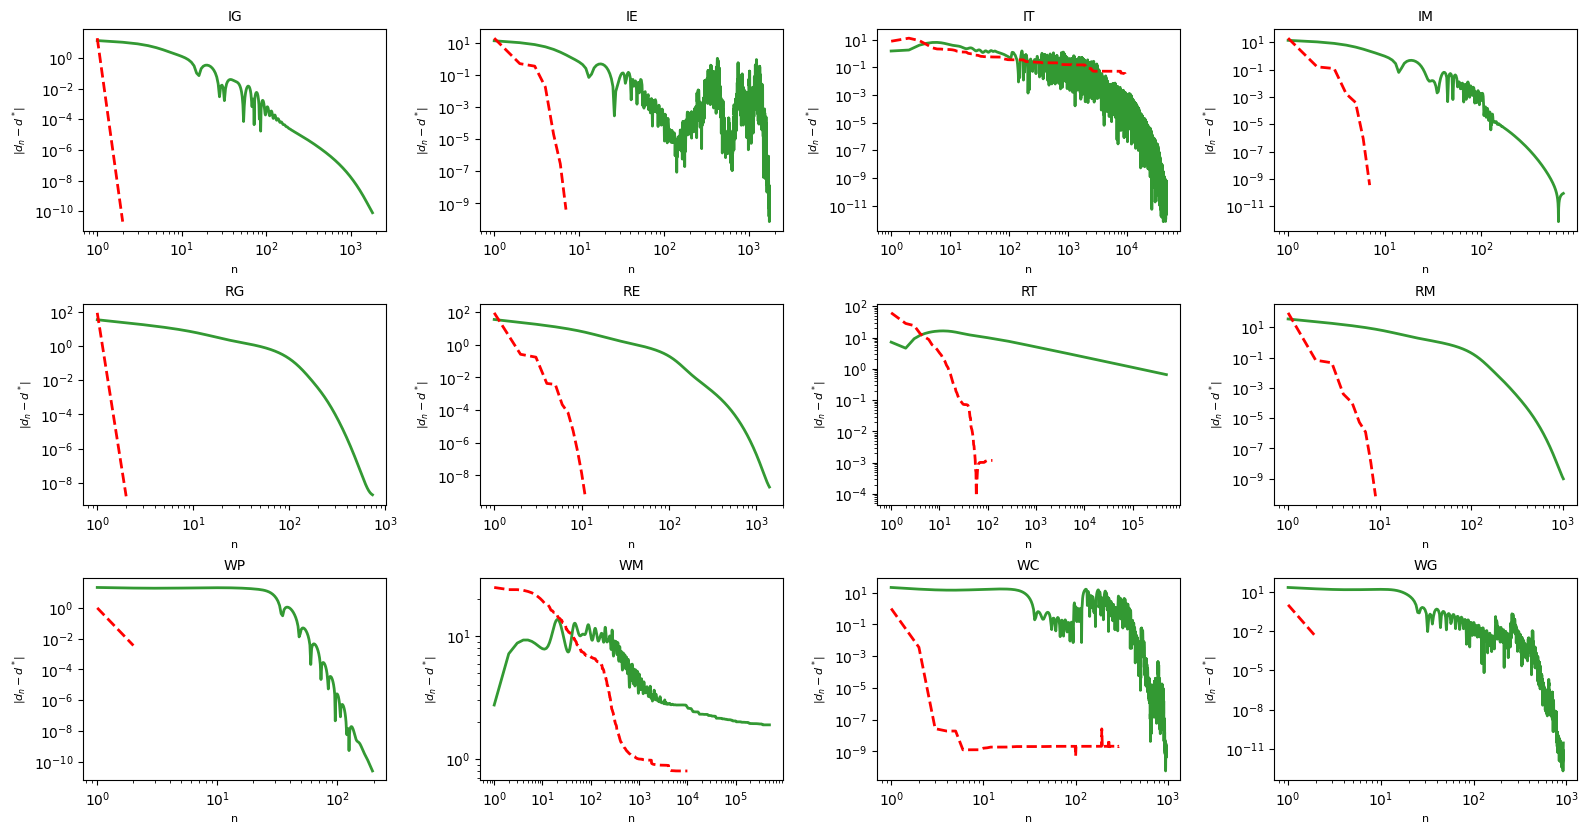

In [14]:
plot_all_tests(tests, x_range=None, y_range=None, semilogy=True)

In [15]:
def plot_one_row(tests,
                row,
                   x_range: Optional[Tuple[float, float]] = None,
                   y_range: Optional[Tuple[float, float]] = None,
                   semilogy: bool = True):
    """
    Plot |loss - ground_truth| for Subgradient and LBFGS across all test JSONs,
    with optional x and y axis limits.
    
    Parameters
    ----------
    input_folder : str
        Directory containing test*.json files.
    x_range : tuple (min_iter, max_iter), optional
        Iteration limits for x-axis.
    y_range : tuple (min_err, max_err), optional
        Error limits for y-axis.
    semilogy : bool
        If True, use log scale for y-axis (semilogy), otherwise linear.
    """
    # load & sort test files
    # pattern = os.path.join(input_folder, "test*.json")
    # paths = sorted(glob.glob(pattern),
    #                key=lambda p: int(re.search(r"test(\d+)\.json$", os.path.basename(p)).group(1)))
    n = len(tests)
    ncols = 4
    nrows = 1
    
    labels = [
        'IG', 'IE', 'IT', 'IM',
        'RG', 'RE', 'RM', 'RT',
        'WP', 'WM', 'WC', 'WG'
    ]
    
    # tests = [tests[i] for i in range(4 * row, 4 * (row+1))]

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

    for ax, test in zip(axes.flatten(), tests):
        # with open(path) as f:
        #     test = json.load(f)
        gt = test['ground_truth']
        sub_hist = test['subgrad_logs'][-1]['loss_history']
        l_hist   = test['lbfgs_logs'][-1]['loss_history']

        # build iteration arrays
        x_sub = [(i+1)*1 for i in range(len(sub_hist))]
        x_l   = [(i+1)*1 for i in range(len(l_hist))]
        y_sub = [abs(val - gt) for val in sub_hist]
        y_l   = [abs(val - gt) for val in l_hist]

        # apply x_range filter if provided
        if x_range:
            xmin, xmax = x_range
            sub_pairs = [(x, y) for x, y in zip(x_sub, y_sub) if xmin <= x <= xmax]
            l_pairs   = [(x, y) for x, y in zip(x_l,   y_l)   if xmin <= x <= xmax]
            x_sub, y_sub = zip(*sub_pairs) if sub_pairs else ([], [])
            x_l,   y_l   = zip(*l_pairs)   if l_pairs   else ([], [])

        # choose plot function
        plot_fn = ax.loglog if semilogy else ax.plot
        plot_fn(x_sub, y_sub, label='Subgradient',
                linestyle='-', linewidth=2.0, alpha=0.8, color='green')
        plot_fn(x_l,   y_l,   label='LBFGS',
                linestyle='--', linewidth=2.0, alpha=1., color='red')

        # set axis limits
        if x_range:
            x_max = min(x_range[1], x_sub[-1])
            ax.set_xlim((x_range[0], x_max))
        if y_range:
            ax.set_ylim(y_range)

        # idx = int(re.search(r"test(\d+)\.json$", os.path.basename(path)).group(1))
        ax.set_title(labels[test['orig_no']], fontsize=10)
        ax.set_xlabel('n', fontsize=8)
        if test['orig_no'] % 4 == 0:
            ax.set_ylabel(r'$| d_n - d^* |$', fontsize=8)
        # ax.legend(fontsize=8)

    # hide any unused subplots
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    fig.subplots_adjust(top=0.90)
    # title = 'Convergence (log scale)' if semilogy else 'Convergence'
    # fig.suptitle(title, fontsize=12)
    plt.show()

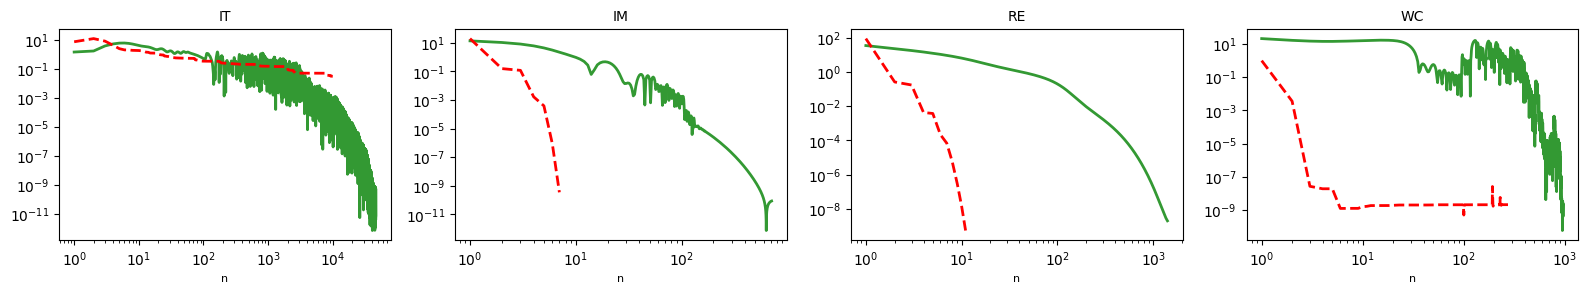

In [16]:
plot_one_row([tests[2], tests[3], tests[5], tests[10]], 2, x_range=None, y_range=None, semilogy=True)